**IMPORTING THE LIBRARIES**

In [1]:
import numpy as np
import os,cv2,sys
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import time
from numpy import savetxt
from numpy import loadtxt
import pandas as pd
import tensorflow as tf
from keras.layers import Conv2D, Add, MaxPooling2D, AveragePooling2D, Activation, Dense, PReLU, Layer, SeparableConv2D, DepthwiseConv2D
from keras.layers import Input, BatchNormalization, GlobalAveragePooling2D, Concatenate, Cropping2D, Multiply, Lambda, Flatten, Reshape
from keras.activations import relu, softmax, sigmoid, tanh
from keras import initializers
from keras.models import Model
from keras.regularizers import l2
import keras.backend as K
import h5py
# import skimage
from sklearn.metrics import accuracy_score
from tensorflow import keras
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from keras.models import load_model, Model

**MOUNTING THE DRIVE**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**LOADING AND PREPROCESSING IMAGE DATA**

In [3]:
data_path='/content/drive/MyDrive/project blood cell/dataset/images/TRAIN'
data_dir_list = ['0', '1', '2', '3']
img_data_list=[]
labels = []

for dataset in data_dir_list:
    img_list=os.listdir(data_path+'/'+ dataset)
    print ('Loaded the images of dataset-'+'{}\n'.format(dataset))
    for img in img_list:
        input_img=cv2.imread(data_path + '/'+ dataset + '/'+ img )
        input_img=cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
        labels.append(dataset)
        input_img_resize=cv2.resize(input_img,(128, 128))
        img_data_list.append(input_img_resize)
#     print(np.array(img_data_list).shape)

label=np.array(labels)
img_data = np.array(img_data_list)
img_data = img_data.astype('float32')
img_data = img_data/255
img_data.shape

Loaded the images of dataset-0

Loaded the images of dataset-1

Loaded the images of dataset-2

Loaded the images of dataset-3



(9965, 128, 128)

**DISPLAYING THE IMAGE**

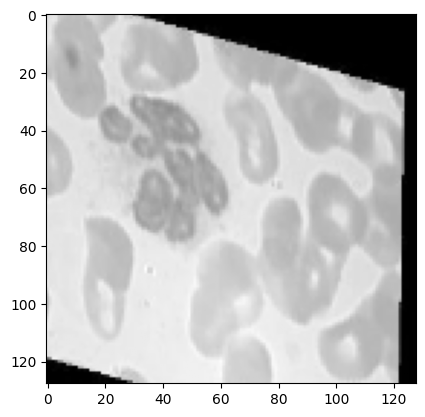

In [4]:
plt.imshow(img_data[33], cmap='gray') # Change 'color' to 'gray' for grayscale images
plt.show()

In [5]:
img_data[0]

array([[0.        , 0.        , 0.        , ..., 0.00784314, 0.02352941,
        0.00392157],
       [0.        , 0.        , 0.        , ..., 0.01176471, 0.01960784,
        0.02745098],
       [0.        , 0.        , 0.        , ..., 0.74509805, 0.15294118,
        0.22352941],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

**DATA PREPARATION FOR MODEL TRAINING**

In [6]:
num_classes = 4 # Number of classes in your dataset
Y = to_categorical(label, num_classes)
x,y = shuffle(img_data,Y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size = 0.1, random_state = 42)
print("Shape of X_train_G:", X_train.shape)
print("Shape of X_test_G:", X_val.shape)
print("Shape of y_train_G:", y_train.shape)
print("Shape of y_test_G:", y_val.shape)

Shape of X_train_G: (8968, 128, 128)
Shape of X_test_G: (997, 128, 128)
Shape of y_train_G: (8968, 4)
Shape of y_test_G: (997, 4)


**RESHAPING THE DATA FOR THE MODEL**

In [7]:
X_train = X_train.reshape(-1, 128, 128, 1)
X_val = X_val.reshape(-1, 128, 128, 1)

**CREATING A CUSTOM KERAS LAYER FOR PATCH EXTRACTION**

In [8]:
import tensorflow as tf
class Patches(Layer):
    def __init__(self, patch_size, **kwargs):
        super(Patches, self).__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, inputs, **kwargs):
        patch = tf.concat((tf.split(inputs, num_or_size_splits= 4, axis=1)), axis=-1)
        patch = tf.concat((tf.split(patch, num_or_size_splits= 4, axis=2)), axis=-1)
        return patch

    def get_config(self):
        config = {'patch_size':self.patch_size}
        base_config = super(Patches, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

**GLOBAL_NET FUNCTION**

In [9]:
def Global_Net(input, eps):
    x_g_1 = DepthwiseConv2D(kernel_size=(7, 7), strides=(1, 1), padding='same', activation=relu)(input)
    x_g_1 = Conv2D(filters=64, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_g_1)
    x_g_1 = BatchNormalization(axis=-1, epsilon=eps)(x_g_1)
    x_g_1 = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x_g_1)
    x_g_1 = DepthwiseConv2D(kernel_size=(3, 3), strides=(1, 1), padding='same', activation=relu)(x_g_1)
    x_g_1 = Conv2D(filters=64, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_g_1)
    x_g_1 = BatchNormalization(axis=-1, epsilon=eps)(x_g_1)
    x_g_1 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x_g_1)

    x_g_2 = DepthwiseConv2D(kernel_size=(3, 3), strides=(1, 1), padding='same', activation=relu)(x_g_1)
    x_g_2 = Conv2D(filters=128, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_g_2)
    x_g_2 = BatchNormalization(axis=-1, epsilon=eps)(x_g_2)
    x_g_2 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x_g_2)

    x_g_3 = DepthwiseConv2D(kernel_size=(3, 3), strides=(1, 1), padding='same', activation=relu)(x_g_2)
    x_g_3 = Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_g_3)
    x_g_3 = BatchNormalization(axis=-1, epsilon=eps)(x_g_3)
    x_g_3 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x_g_3)

    x_g_4 = DepthwiseConv2D(kernel_size=(3, 3), strides=(1, 1), padding='same', activation=relu)(x_g_3)
    x_g_4 = Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_g_4)
    x_g_4 = BatchNormalization(axis=-1, epsilon=eps)(x_g_4)
    x_g_4 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x_g_4)
    return x_g_4

**LOCAL_NET FUNCTION**

In [10]:
def Local_Net(input, eps):
    x_l_1 = DepthwiseConv2D(kernel_size=(7, 7), strides=(1, 1), padding='same', activation=relu)(input)
    x_l_1 = Conv2D(filters=128, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_l_1)
    x_l_1 = BatchNormalization(axis=-1, epsilon=eps)(x_l_1)
    x_l_1 = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x_l_1)
    x_l_1 = DepthwiseConv2D(kernel_size=(3, 3), strides=(1, 1), padding='same', activation=relu)(x_l_1)
    x_l_1 = Conv2D(filters=128, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_l_1)
    x_l_1 = BatchNormalization(axis=-1, epsilon=eps)(x_l_1)
    x_l_1 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x_l_1)

    x_l_2 = DepthwiseConv2D(kernel_size=(3, 3), strides=(1, 1), padding='same', activation=relu)(x_l_1)
    x_l_2 = Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_l_2)
    x_l_2 = BatchNormalization(axis=-1, epsilon=eps)(x_l_2)
    x_l_2 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x_l_2)

    x_l_3 = DepthwiseConv2D(kernel_size=(3, 3), strides=(1, 1), padding='same', activation=relu)(x_l_2)
    x_l_3 = Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_l_3)
    x_l_3 = BatchNormalization(axis=-1, epsilon=eps)(x_l_3)
    x_l_3 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x_l_3)

    x_l_4 = DepthwiseConv2D(kernel_size=(3, 3), strides=(1, 1), padding='same', activation=relu)(x_l_3)
    x_l_4 = Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='relu')(x_l_4)
    x_l_4 = BatchNormalization(axis=-1, epsilon=eps)(x_l_4)
    x_l_4 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x_l_4)

    return x_l_4

**CALCULATING COSINE SIMILARITY**

In [11]:
import tensorflow as tf
from tensorflow.keras import backend as K

def Cosin_similarity(inputs):
    dot1 = K.batch_dot(inputs[0], inputs[1], axes=[1, 1])  # Compute the dot product
    dot2 = K.batch_dot(inputs[0], inputs[0], axes=[1, 1])  # Compute dot product of first vector with itself
    dot3 = K.batch_dot(inputs[1], inputs[1], axes=[1, 1])  # Compute dot product of second vector with itself
    max_val = K.maximum(K.sqrt(dot2 * dot3), K.epsilon())  # Take square root and avoid division by zero
    return dot1 / max_val

**THE Bund FUNCTION**

In [12]:
def Bund(input):
    alpha_1 = input[0]
    alpha_2 = input[1]

    alpha_l = alpha_1/(alpha_1+alpha_2)
    alpha_g = alpha_2/(alpha_1+alpha_2)

    return alpha_l, alpha_g

**DEFINING THE ENHANCE_NET MODEL**

In [13]:
from tensorflow.keras.optimizers import Nadam # Import Nadam optimizer

def Enhance_Net(eps = 1.1e-5):
    input1 = Input((128, 128, 1))

    x1 = Conv2D(filters=16, kernel_size=(3, 3), activation='relu')(input1)
    x3 = Conv2D(filters=32, kernel_size=(3, 3), activation='relu')(x1)

    x_l_0 = Patches(patch_size=32)(x3)
    x_g_0 = x3
    x_l = Local_Net(x_l_0, eps)
    x_g = Global_Net(x_g_0, eps)

    x_l = GlobalAveragePooling2D()(x_l)
    x_g = GlobalAveragePooling2D()(x_g)

    x_lg = Multiply()([x_l, x_g])
    x_gl = Add()([x_l, x_g])

    x_c = Concatenate()([x_lg, x_gl])

    x_l = Dense(units=512, activation='relu')(x_l)
    x_g = Dense(units=512, activation='relu')(x_g)

    share_1 = Dense(units=1024, activation='relu')
    share_2 = Dense(units=1024, activation='relu')

    x_l = share_1(x_l)
    x_g = share_1(x_g)
    x_c = share_1(x_c)

    x_l = share_2(x_l)
    x_g = share_2(x_g)
    x_c = share_2(x_c)

    alpha_1 = Lambda(Cosin_similarity, output_shape=(1,))([x_l, x_c])  # Output shape (None, 1)
    alpha_2 = Lambda(Cosin_similarity, output_shape=(1,))([x_g, x_c])  # Output shape (None, 1)

    alpha_l, alpha_g = Lambda(Bund, output_shape=[(1024,), (1024,)])([alpha_1, alpha_2])  # Output shape (None, 1024)

    out_l = Multiply()([alpha_l, x_l])
    out_g = Multiply()([alpha_g, x_g])

    out = Concatenate()([out_l, out_g])
    out = Dense(units=4, activation='softmax')(out)

    model = Model([input1], [out])
    return model

model = Enhance_Net(eps = 1.1e-5)
opt = Nadam(learning_rate=0.0001) # Now Nadam is recognized
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['acc'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 124, 124,  │      4,640 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, 31, 31,    │          0 │ conv2d_1[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 31, 31,    │     25,600 │ patches[0][0]     │
│ (DepthwiseConv2D)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_5  │ (None, 124, 124,  │      1,600 │ conv2d_1[0][0]    │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 31, 31,    │     65,664 │ depthwise_conv2d… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 124, 124,  │      2,112 │ depthwise_conv2d… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 31, 31,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 124, 124,  │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 124, 124,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 31, 31,    │      1,280 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_6  │ (None, 124, 124,  │        640 │ max_pooling2d_5[… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 31, 31,    │     16,512 │ depthwise_conv2d… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 124, 124,  │      4,160 │ depthwise_conv2d… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        512 │ conv2d_3[0][0]  

 Total params: 2,258,436 (8.62 MB)

 Trainable params: 2,254,852 (8.60 MB)

 Non-trainable params: 3,584 (14.00 KB)

**MODEL TRAINING AND OPTIMIZATION**

In [14]:
# model.compile(optimizer= Adam(learning_rate=0.0001, weight_decay = 1e-6), loss='categorical_crossentropy', metrics=['accuracy'])
from keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping = EarlyStopping(
                              patience=30,
                              min_delta=0.001,
                              monitor="val_acc",
                              restore_best_weights=True
                              )
# Define the model checkpoint callback to save the best weights
checkpoint = ModelCheckpoint('/content/drive/MyDrive/project blood cell/'+'-{epoch:02d}.h5', monitor='val_acc', save_best_only=True)

history = model.fit([X_train], y_train, batch_size= 16, epochs= 5,
                    verbose=1, validation_data=([X_val], y_val), callbacks=[early_stopping, checkpoint], shuffle = True)

Epoch 1/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - acc: 0.4219 - loss: 1.1871

561/561 ━━━━━━━━━━━━━━━━━━━━ 89s 99ms/step - acc: 0.4221 - loss: 1.1867 - val_acc: 0.2427 - val_loss: 1.3925
Epoch 2/5
560/561 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - acc: 0.7913 - loss: 0.5335

561/561 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - acc: 0.7914 - loss: 0.5333 - val_acc: 0.3079 - val_loss: 2.2678
Epoch 3/5
560/561 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.8790 - loss: 0.3052

561/561 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - acc: 0.8790 - loss: 0.3051 - val_acc: 0.8185 - val_loss: 0.5614
Epoch 4/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - acc: 0.9251 - loss: 0.1910 - val_acc: 0.3380 - val_loss: 2.9365
Epoch 5/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - acc: 0.9356 - loss: 0.1616 - val_acc: 0.7984 - val_loss: 0.6222


**LOADING THE TEST IMAGES**

In [15]:
data_path='/content/drive/MyDrive/project blood cell/dataset/images/TEST'
data_dir_list = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
img_data_list=[]
labels = []

for dataset in data_dir_list:
    # Check if the directory exists before trying to access it
    dir_path = os.path.join(data_path, dataset)
    if os.path.exists(dir_path):
        img_list=os.listdir(dir_path)
        print ('Loaded the images of dataset-'+'{}\n'.format(dataset))
        for img in img_list:
            input_img=cv2.imread(os.path.join(dir_path, img))
            # Check if image loading was successful
            if input_img is not None:
                input_img=cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
                labels.append(dataset)
                input_img_resize=cv2.resize(input_img,(128, 128))
                img_data_list.append(input_img_resize)
            else:
                print(f"Error loading image: {os.path.join(dir_path, img)}")

# Check if img_data_list is empty
if not img_data_list:
    print("Error: No images were loaded. Check your data path and directory structure.")
else:
    label_test=np.array(labels)
    img_data_test = np.array(img_data_list)
    img_data_test = img_data_test.astype('float32')
    img_data_test = img_data_test/255
    print(img_data_test.shape)

Loaded the images of dataset-EOSINOPHIL

Loaded the images of dataset-LYMPHOCYTE

Loaded the images of dataset-MONOCYTE

Loaded the images of dataset-NEUTROPHIL

(2487, 128, 128)


**RESHAPING THE TEST IMAGE**

In [16]:
img_data_test = img_data_test.reshape(-1, 128, 128, 1)

**PREDICTING THE TEST SET RESULTS**

In [17]:
pred = model.predict(img_data_test)
print("Y_pred:", pred)
print("*****************")
y_pred = np.argmax(pred, axis = 1)
print("Y_pred:", y_pred)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 128, 128, 1))
  warnings.warn(msg)


77/78 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 128, 128, 1))
  warnings.warn(msg)


78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step
Y_pred: [[3.06285024e-01 2.26742402e-01 1.15074590e-01 3.51897955e-01]
 [7.27284849e-01 1.86431348e-01 5.20035997e-02 3.42801809e-02]
 [1.18405791e-02 7.88124800e-01 9.91451016e-05 1.99935392e-01]
 ...
 [1.76116992e-02 3.66637905e-05 3.73321891e-05 9.82314348e-01]
 [7.03102499e-02 2.46983976e-03 3.76947632e-04 9.26842928e-01]
 [3.35795246e-02 4.03033191e-05 1.36146685e-02 9.52765405e-01]]
*****************
Y_pred: [3 0 1 ... 3 3 3]


**CONVERTING LABELS TO ONE-HOT ENCODING AND EXTRACTING TRUE LABELS**

In [18]:
# Assuming label_test currently contains strings like 'EOSINOPHIL', 'LYMPHOCYTE', etc.
class_mapping = {
    'EOSINOPHIL': 0,
    'LYMPHOCYTE': 1,
    'MONOCYTE': 2,
    'NEUTROPHIL': 3
}

# Create a numerical label array using the mapping
numerical_labels = [class_mapping[label] for label in label_test]

# Now use the numerical labels with to_categorical
num_classes = 4  # Number of classes in your dataset
Y = to_categorical(numerical_labels, num_classes)  # Use numerical_labels instead of label_test
y_true = np.argmax(Y, axis=1)

**IMPORTING THE CLASSIFICATION_REPORT FUNCTION**

In [19]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.34      0.39      0.36       623
           1       0.72      1.00      0.83       620
           2       0.94      0.40      0.56       620
           3       0.66      0.66      0.66       624

    accuracy                           0.61      2487
   macro avg       0.66      0.61      0.60      2487
weighted avg       0.66      0.61      0.60      2487



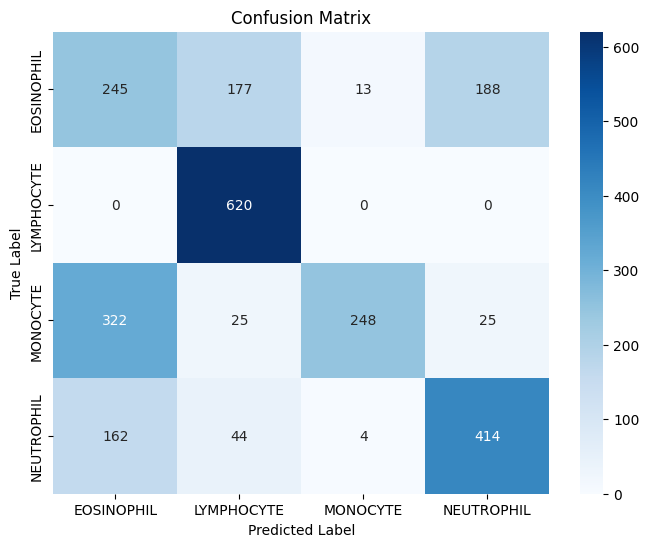

              precision    recall  f1-score   support

  EOSINOPHIL       0.34      0.39      0.36       623
  LYMPHOCYTE       0.72      1.00      0.83       620
    MONOCYTE       0.94      0.40      0.56       620
  NEUTROPHIL       0.66      0.66      0.66       624

    accuracy                           0.61      2487
   macro avg       0.66      0.61      0.60      2487
weighted avg       0.66      0.61      0.60      2487



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Assuming y_true and y_pred are already defined from your previous code

# Making the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Define target names (replace with your actual class labels)
target_names = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Printing the classification report
print(classification_report(y_true, y_pred, target_names=target_names))


**CALCULATING AND PLOTTING ROC CURVES AND AUC FOR EACH CLASS**

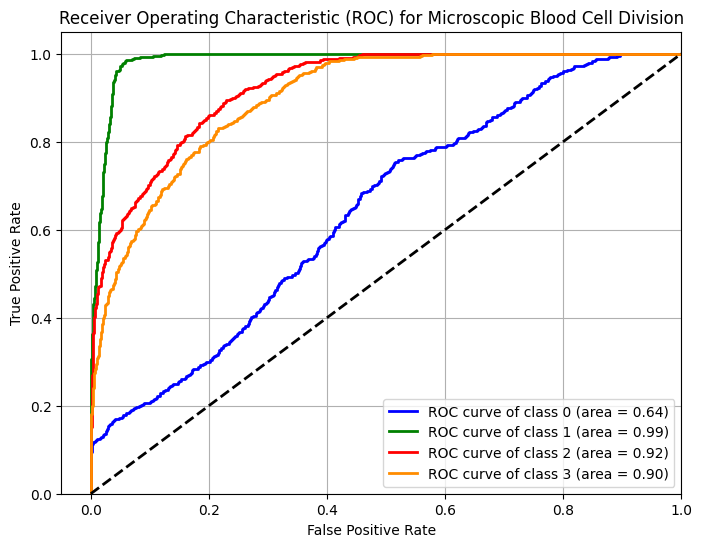

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Assuming Y and pred are already defined from your blood cell division code
# Example:
# Y = ... # Your true labels (one-hot encoded)
# pred = ... # Your model's predicted probabilities

fpr = dict()
tpr = dict()
roc_auc = dict()
lw = 2

# Assuming you have 4 classes (adjust the range if needed)
for i in range(4):  # Iterate over each class
    fpr[i], tpr[i], _ = roc_curve(Y[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'green', 'red', 'darkorange'])

plt.figure(figsize=(8, 6))  # Adjust figure size as needed

for i, color in zip(range(4), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Microscopic Blood Cell Division')
plt.legend(loc="lower right")
plt.grid()
plt.show()

**LOADING AND PREPROCESSING A NEW IMAGE FOR PREDICTION**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction for the new image: LYMPHOCYTE


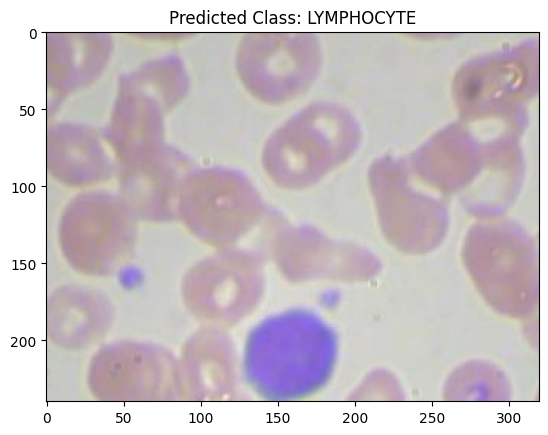

In [23]:

from google.colab import drive
from keras.optimizers import Nadam
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from itertools import cycle


drive.mount('/content/drive')

# Assuming 'new_image_path' holds the path to your new image file
new_image_path = '/content/drive/MyDrive/project blood cell/dataset/images/NEW_IMAGES/L.jpeg' #@param {type:"string"}

# Load and preprocess the new image
input_img = cv2.imread(new_image_path)
if input_img is None:
  print(f"Error: Could not load image at {new_image_path}")
else:
  input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
  input_img_resize = cv2.resize(input_img, (128, 128))
  img_data_new = np.array(input_img_resize)
  img_data_new = img_data_new.astype('float32') / 255
  img_data_new = img_data_new.reshape(-1, 128, 128, 1)

  # Predict the class for the new image
  y_pred_new = model.predict(img_data_new)
  y_pred_new = np.argmax(y_pred_new, axis=1) # Get the predicted class index

  #The following code was indented to be inside the else block
  class_names = {
      0: "EOSINOPHIL",
      1: "LYMPHOCYTE",
      2: "MONOCYTE",
      3: "NEUTROPHIL"
  }

  # Get the predicted class number
  predicted_class_number = y_pred_new[0]  # Access the first element (predicted class)

  # Get the class name using the dictionary
  predicted_class_name = class_names.get(predicted_class_number, "Unknown")

  print("Prediction for the new image:", predicted_class_name)

# Load the image in color
input_img = cv2.imread(new_image_path)

if input_img is None:
    print(f"Error: Could not load image at {new_image_path}")
else:
    # Convert BGR to RGB for matplotlib
    input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.imshow(input_img_rgb)
    plt.title(f"Predicted Class: {predicted_class_name}")
    plt.show()
